# Student Performance Analysis
**Cognevance Technologies — Level 1 Project**

This notebook analyzes student academic performance data to find patterns between
attendance, study habits, and marks, using basic data analytics techniques in Python.

**Workflow:** Load data → Clean → Explore → Visualize → Generate insights


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 2. Load the dataset

The dataset (`student_performance_raw.csv`) contains 300+ students with attendance,
study hours, and marks across 4 subjects. A few missing values and duplicate rows
were intentionally left in to practice the cleaning step.

In [2]:
df = pd.read_csv("student_performance_raw.csv")
print(df.shape)
df.head()


(302, 13)


,student_id,name,gender,grade,attendance_pct,study_hours_per_week,math_marks,science_marks,english_marks,social_studies_marks,total_marks,average_marks,result
0,STU1000,Reyansh Gupta,Male,10,97.0,NaN,67.0,65.1,71.8,73.7,277.6,69.4,Pass
1,STU1001,Pooja Pillai,Female,9,74.3,7.0,58.5,52.8,55.0,66.2,232.5,58.1,Pass
2,STU1002,Ananya Kulkarni,Male,10,80.3,9.8,40.7,48.5,43.1,30.8,163.1,40.8,Pass
3,STU1003,Pooja Iyer,Female,10,78.4,8.6,59.1,56.8,53.4,58.7,228.0,57.0,Pass
4,STU1004,Reyansh Mehta,Male,11,100.0,9.6,80.4,73.8,73.9,75.0,303.1,75.8,Pass


## 3. Clean & preprocess the data

In [3]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated(subset="student_id").sum())


Missing values:
 student_id              0
name                    0
gender                  0
grade                   0
attendance_pct          7
study_hours_per_week    4
math_marks              0
science_marks           0
english_marks           0
social_studies_marks    0
total_marks             0
average_marks           0
result                  0
dtype: int64

Duplicate rows: 2


In [4]:
# Drop duplicate students
df = df.drop_duplicates(subset="student_id")

# Fill missing attendance / study hours with the median (robust to outliers)
df["attendance_pct"] = df["attendance_pct"].fillna(df["attendance_pct"].median())
df["study_hours_per_week"] = df["study_hours_per_week"].fillna(df["study_hours_per_week"].median())

df["attendance_pct"] = df["attendance_pct"].round(1)
df["study_hours_per_week"] = df["study_hours_per_week"].round(1)

df.to_csv("student_performance_clean.csv", index=False)
print("Clean shape:", df.shape)


Clean shape: (300, 13)


## 4. Explore marks, attendance, and performance trends

In [5]:
df[["attendance_pct", "study_hours_per_week", "math_marks", "science_marks",
    "english_marks", "social_studies_marks", "average_marks"]].describe().round(1)


,attendance_pct,study_hours_per_week,math_marks,science_marks,english_marks,social_studies_marks,average_marks
count,300.0,300.0,300.0,300.0,300.0,300.0,300.0
mean,80.4,10.6,57.7,58.5,58.5,58.2,58.2
std,11.9,4.3,12.9,13.3,14.8,14.9,12.6
min,46.6,1.0,20.4,24.0,18.2,19.6,26.0
25%,72.0,7.7,48.6,49.2,49.4,47.1,49.9
50%,80.4,10.4,58.1,58.4,58.0,58.2,57.8
75%,89.6,13.4,66.8,67.6,68.6,68.1,67.2
max,100.0,23.1,90.3,99.4,100.0,96.3,94.7


In [6]:
pass_rate = (df["result"] == "Pass").mean() * 100
print(f"Overall pass rate: {pass_rate:.1f}%")


Overall pass rate: 93.3%


## 5. Visualizations

### 5.1 Distribution of average marks

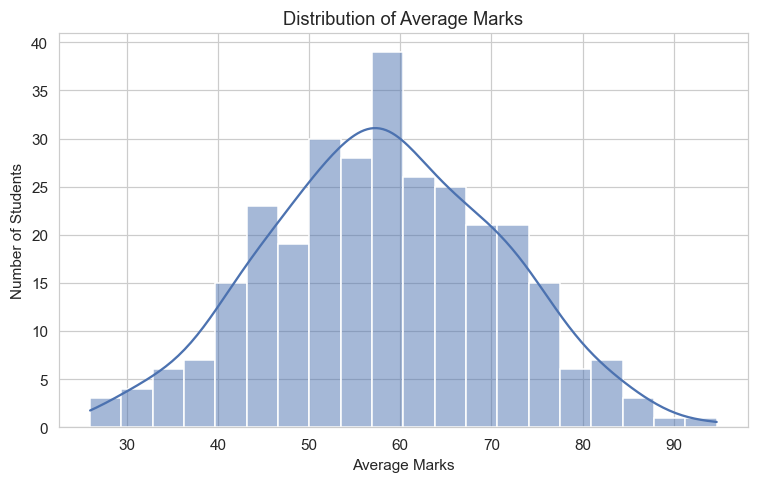

In [7]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df["average_marks"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Average Marks")
plt.xlabel("Average Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("chart_01_marks_distribution.png")
plt.show()


### 5.2 Pass vs fail rate

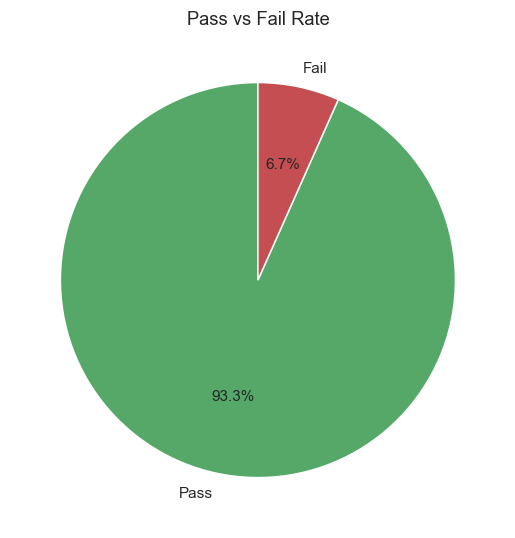

In [8]:
counts = df["result"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=["#55A868", "#C44E52"], startangle=90)
plt.title("Pass vs Fail Rate")
plt.tight_layout()
plt.savefig("chart_02_pass_fail_pie.png")
plt.show()


### 5.3 Attendance vs marks relationship

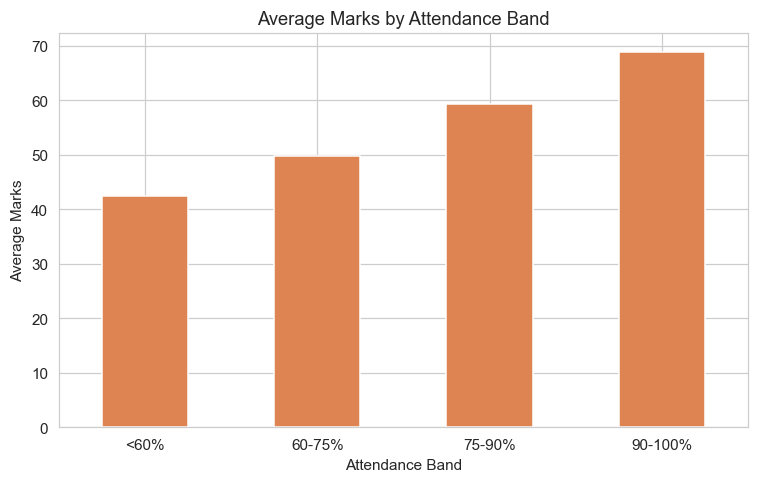

attendance_band
<60%       42.5
60-75%     49.8
75-90%     59.4
90-100%    68.9
Name: average_marks, dtype: float64

In [9]:
df["attendance_band"] = pd.cut(df["attendance_pct"], bins=[0, 60, 75, 90, 100],
                                labels=["<60%", "60-75%", "75-90%", "90-100%"])
band_avg = df.groupby("attendance_band", observed=True)["average_marks"].mean().round(1)

plt.figure(figsize=(7, 4.5))
band_avg.plot(kind="bar", color="#DD8452")
plt.title("Average Marks by Attendance Band")
plt.xlabel("Attendance Band")
plt.ylabel("Average Marks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_03_attendance_band_bar.png")
plt.show()

band_avg


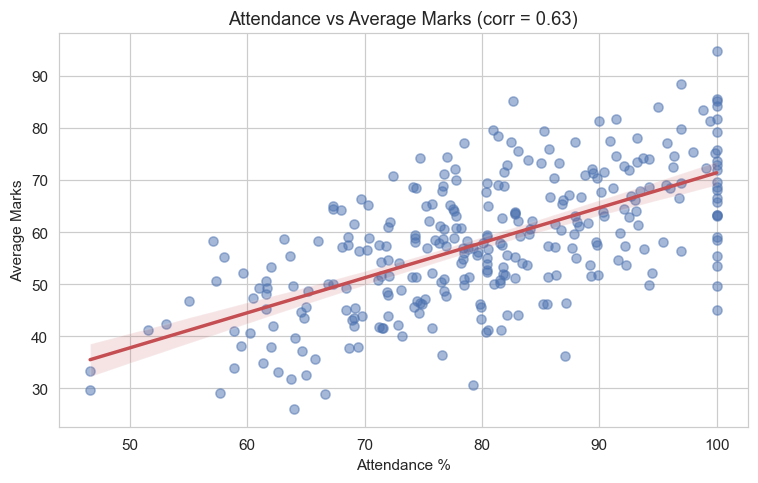

Correlation (attendance vs average marks): 0.63


In [10]:
corr_attendance_avg = df["attendance_pct"].corr(df["average_marks"])

plt.figure(figsize=(7, 4.5))
sns.regplot(data=df, x="attendance_pct", y="average_marks",
            scatter_kws={"alpha": 0.5, "color": "#4C72B0"}, line_kws={"color": "#C44E52"})
plt.title(f"Attendance vs Average Marks (corr = {corr_attendance_avg:.2f})")
plt.xlabel("Attendance %")
plt.ylabel("Average Marks")
plt.tight_layout()
plt.savefig("chart_04_attendance_vs_marks_scatter.png")
plt.show()

print(f"Correlation (attendance vs average marks): {corr_attendance_avg:.2f}")


### 5.4 Subject-wise performance

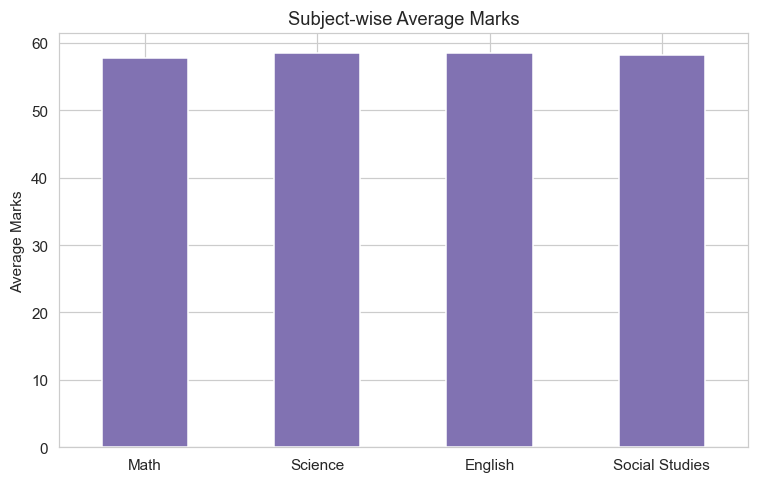

Math              57.7
Science           58.5
English           58.5
Social Studies    58.2
dtype: float64

In [11]:
subj_avg = df[["math_marks", "science_marks", "english_marks", "social_studies_marks"]].mean()
subj_avg.index = ["Math", "Science", "English", "Social Studies"]

plt.figure(figsize=(7, 4.5))
subj_avg.round(1).plot(kind="bar", color="#8172B2")
plt.title("Subject-wise Average Marks")
plt.ylabel("Average Marks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_05_subject_avg_bar.png")
plt.show()

subj_avg.round(1)


## 6. Insights & recommendations

Based on the analysis above:

1. **Attendance strongly predicts performance.** Students with 90–100% attendance
   average roughly 27 points higher than students below 60% attendance, and the
   correlation between attendance and average marks is ~0.6 (moderately strong,
   positive).
2. **Study hours also matter, but less than attendance.** The correlation between
   weekly study hours and average marks is ~0.5.
3. **Pass rate is high overall (~93%)**, but the students who fail are concentrated
   in the low-attendance band, suggesting attendance policy/interventions would have
   the biggest impact on reducing failures.
4. **Subject performance is fairly even** across Math, Science, English, and Social
   Studies, with no subject dramatically underperforming the others.
5. **Recommendation:** Prioritize attendance-improvement interventions (reminders,
   parent communication, mentoring) for students below 75% attendance, since this is
   the band with the steepest marks drop-off.